DiGraph with 57771 nodes and 1094895 edges
resolution = 0.01
Counter({0: 902, 1: 855, 2: 854, 3: 802, 4: 600, 5: 599, 6: 596, 7: 583, 8: 565, 9: 532, 10: 514, 11: 511, 13: 508, 12: 508, 14: 504, 15: 502, 16: 483, 17: 483, 18: 462, 19: 460, 20: 456, 21: 453, 22: 449, 23: 412, 24: 411, 25: 399, 26: 359, 27: 334, 28: 315, 29: 315, 30: 313, 31: 311, 32: 307, 33: 295, 34: 270, 35: 263, 36: 260, 37: 258, 38: 256, 39: 255, 40: 254, 41: 244, 42: 220, 43: 219, 44: 214, 45: 211, 46: 163, 47: 158, 48: 157, 49: 150, 50: 147, 51: 143, 52: 134, 53: 133, 54: 125, 55: 111, 56: 109, 57: 108, 58: 103, 59: 102, 60: 98, 61: 96, 62: 89, 63: 84, 64: 79, 65: 70, 66: 65, 67: 64, 69: 63, 68: 63, 72: 62, 73: 62, 71: 62, 74: 62, 70: 62, 75: 61, 78: 61, 77: 61, 76: 61, 79: 60, 80: 59, 81: 57, 82: 57, 83: 55, 84: 55, 85: 55, 86: 53, 87: 52, 88: 51, 91: 50, 90: 50, 89: 50, 92: 49, 93: 49, 95: 48, 94: 48, 96: 47, 97: 47, 98: 46, 99: 45, 100: 44, 101: 43, 102: 42, 103: 41, 104: 40, 105: 40, 106: 39, 108: 38, 107: 38,

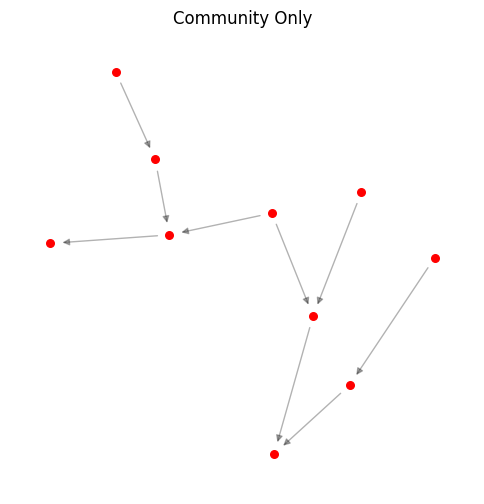

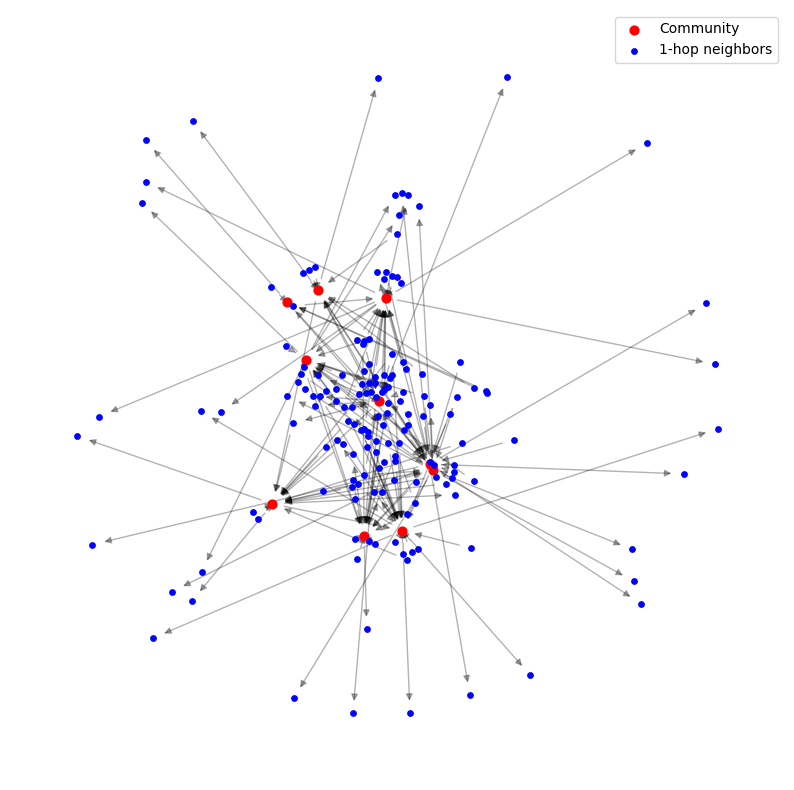

In [3]:
import networkx as nx
import pickle
import igraph as ig
import leidenalg
import statistics
import matplotlib.pyplot as plt
from collections import Counter

# Visualize Example Community and one-hop neighbors

# ----------------------------
# Load NetworkX graph
# ----------------------------
with open("../data/neuron_graph.gpickle", "rb") as f:
    G = pickle.load(f)

print(G)

# ----------------------------
# Convert to igraph (preserve node IDs)
# ----------------------------
g = ig.Graph.TupleList(
    G.edges(),
    directed=True,
    vertex_name_attr="name"
)

# ----------------------------
# Leiden partition
# ----------------------------
partitions = [0.01]
medians = []
lengths = []

for p in partitions:
    print("resolution =", p)

    partition = leidenalg.find_partition(
        g,
        leidenalg.CPMVertexPartition,
        resolution_parameter=p
    )

    print(Counter(partition.membership))

    sizes = list(Counter(partition.membership).values())
    medians.append(statistics.median(sizes))

    communities = [
        [g.vs[v]["name"] for v in community]
        for community in partition
    ]

    lengths.append(len(communities))
    print("num communities:", len(communities))

print("median sizes:", medians)
print("num communities:", lengths)

#Choose a single community
idx = int(len(communities) / 2)
community_nodes = set(communities[idx])

print("community size:", len(community_nodes))

#community nodes subgraph
C =G.subgraph(community_nodes).copy()
plt.figure(figsize=(6, 6))
pos_c = nx.spring_layout(C, seed=42)

nx.draw_networkx_edges(C, pos_c, alpha=0.3)
nx.draw_networkx_nodes(
    C,
    pos_c,
    node_color="red",
    node_size=30
)

plt.title("Community Only")
plt.axis("off")
plt.show()

#Find community and 1-hop neighbors
neighbors = set()
for n in community_nodes:
    neighbors.update(G.predecessors(n))
    neighbors.update(G.successors(n))

neighbors -= community_nodes

H = G.subgraph(community_nodes | neighbors).copy()

pos = nx.spring_layout(H, seed=42)

#Draw edge only connecting to community nodes
community_edges = [
    (u, v) for u, v in H.edges()
    if (u in community_nodes) or (v in community_nodes)
]

plt.figure(figsize=(10, 10))

nx.draw_networkx_edges(
    H,
    pos,
    edgelist=community_edges,
    alpha=0.3
)

nx.draw_networkx_nodes(
    H,
    pos,
    nodelist=list(community_nodes),
    node_color="red",
    node_size=40,
    label="Community"
)

nx.draw_networkx_nodes(
    H,
    pos,
    nodelist=list(neighbors),
    node_color="blue",
    node_size=15,
    label="1-hop neighbors"
)

plt.legend()
plt.axis("off")
plt.show()


median sizes: [10]
num communities: [4415]
community size: 10


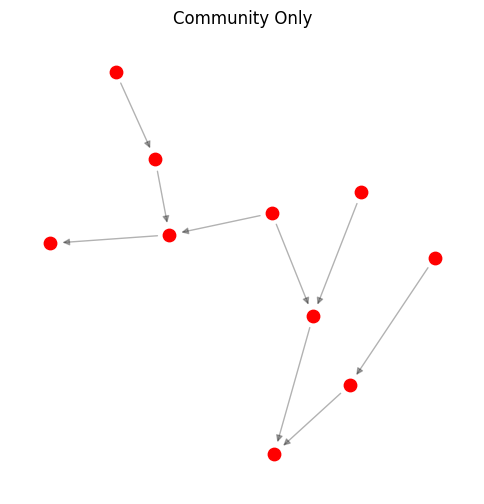

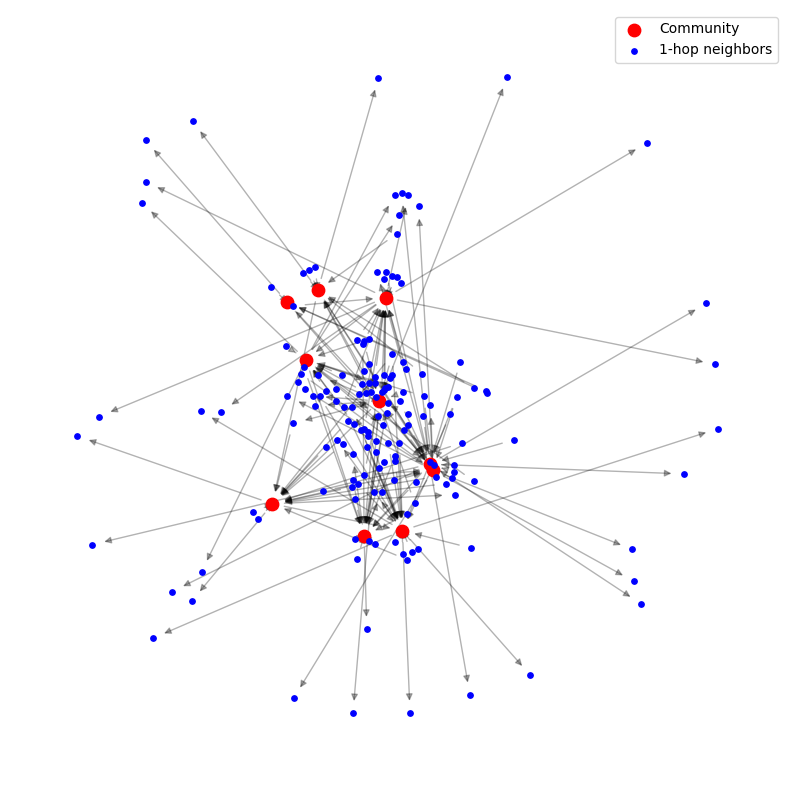

In [16]:

print("median sizes:", medians)
print("num communities:", lengths)

#Choose a single community
idx = int(len(communities) / 2)
community_nodes = set(communities[idx])

print("community size:", len(community_nodes))

#community nodes subgraph
C =G.subgraph(community_nodes).copy()
plt.figure(figsize=(6, 6))
pos_c = nx.spring_layout(C, seed=42)

nx.draw_networkx_edges(C, pos_c, alpha=0.3)
nx.draw_networkx_nodes(
    C,
    pos_c,
    node_color="red",
    node_size=80
)

plt.title("Community Only")
plt.axis("off")
plt.show()

#Find community and 1-hop neighbors
neighbors = set()
for n in community_nodes:
    neighbors.update(G.predecessors(n))
    neighbors.update(G.successors(n))

neighbors -= community_nodes

H = G.subgraph(community_nodes | neighbors).copy()

pos = nx.spring_layout(H, seed=42)

#Draw edge only connecting to community nodes
community_edges = [
    (u, v) for u, v in H.edges()
    if (u in community_nodes) or (v in community_nodes)
]

plt.figure(figsize=(10, 10))

nx.draw_networkx_edges(
    H,
    pos,
    edgelist=community_edges,
    alpha=0.3
)

nx.draw_networkx_nodes(
    H,
    pos,
    nodelist=list(community_nodes),
    node_color="red",
    node_size=80,
    label="Community"
)

nx.draw_networkx_nodes(
    H,
    pos,
    nodelist=list(neighbors),
    node_color="blue",
    node_size=15,
    label="1-hop neighbors"
)

plt.legend()
plt.axis("off")
plt.show()


In [5]:
# Directed graph: count in + out degree
community_degrees_only = [
    C.in_degree(n) + C.out_degree(n)
    for n in C.nodes()
]

avg_community_only = sum(community_degrees_only) / len(community_degrees_only)

print("Avg connections per node (community only):", avg_community_only)


Avg connections per node (community only): 1.8


In [14]:
neighbor_unique_degrees = []

for n in neighbors:
    uniq_neighbors = set(G.predecessors(n)) | set(G.successors(n))
    uniq_neighbors &= community_nodes  # ONLY connections to community
    neighbor_unique_degrees.append(len(uniq_neighbors))

avg_neighbor_unique = sum(neighbor_unique_degrees) / len(neighbor_unique_degrees)

print("Avg UNIQUE connections per 1-hop neighbor:", avg_neighbor_unique)


Avg UNIQUE connections per 1-hop neighbor: 1.0875
